In [ ]:
import pandas as pd
import xarray as xr

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#visualization

In [ ]:
df= pd.read_csv('/content/drive/MyDrive/Work @Weclimb/Processed data/daily average/file(1950-2023).csv')

In [ ]:
df

,lon,lat,time,utci,utci_celsius,stress_category
0,73.5,32.5,1950-01-01,279.84690,6.69690,Slight Cold Stress
1,73.5,32.5,1950-01-02,281.07953,7.92953,Slight Cold Stress
2,73.5,32.5,1950-01-03,282.05853,8.90853,Slight Cold Stress
3,73.5,32.5,1950-01-04,284.54535,11.39535,No thermal stress
4,73.5,32.5,1950-01-05,283.68002,10.53002,No thermal stress
...,...,...,...,...,...,...
5959481,77.5,29.5,2023-10-26,294.64430,21.49430,No thermal stress
5959482,77.5,29.5,2023-10-27,294.22726,21.07726,No thermal stress
5959483,77.5,29.5,2023-10-28,296.92572,23.77572,No thermal stress
5959484,77.5,29.5,2023-10-29,297.93546,24.78546,No thermal stress


In [ ]:
import pandas as pd

df['time'] = pd.to_datetime(df['time'])
df.drop(['utci', 'stress_category'], axis=1, inplace=True)

# Display the modified DataFrame
print(df)


          lon   lat       time  utci_celsius
0        73.5  32.5 1950-01-01       6.69690
1        73.5  32.5 1950-01-02       7.92953
2        73.5  32.5 1950-01-03       8.90853
3        73.5  32.5 1950-01-04      11.39535
4        73.5  32.5 1950-01-05      10.53002
...       ...   ...        ...           ...
5959481  77.5  29.5 2023-10-26      21.49430
5959482  77.5  29.5 2023-10-27      21.07726
5959483  77.5  29.5 2023-10-28      23.77572
5959484  77.5  29.5 2023-10-29      24.78546
5959485  77.5  29.5 2023-10-30      25.13714

[5959486 rows x 4 columns]


In [ ]:
df['month'] = df['time'].dt.month
df['year'] = df['time'].dt.year

# Now, group by year and month, and calculate the mean for each group
mdf = df.groupby(['year', 'month', 'lat', 'lon']).mean()

# Reset index to make the year, month, lat, and lon columns regular columns
mdf.reset_index(inplace=True)

# Display the resulting DataFrame
print(mdf)

        year  month   lat    lon  utci_celsius
0       1950      1  29.5  73.50     12.004224
1       1950      1  29.5  73.75     12.068523
2       1950      1  29.5  74.00     12.196113
3       1950      1  29.5  74.25     12.127976
4       1950      1  29.5  74.50     12.033265
...      ...    ...   ...    ...           ...
195801  2023     10  32.5  76.50      0.914312
195802  2023     10  32.5  76.75     -3.600797
195803  2023     10  32.5  77.00     -3.600797
195804  2023     10  32.5  77.25     -6.319414
195805  2023     10  32.5  77.50     -8.400812

[195806 rows x 5 columns]


<ipython-input-5-a3875df10f7f>:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mdf = df.groupby(['year', 'month', 'lat', 'lon']).mean()


In [ ]:
mdf.head(100)

In [ ]:
import pandas as pd

# Assuming your data is stored in a DataFrame called df

# Filter data for January (month 1)
january_data = mdf[mdf['month'] == 1]
february_data = mdf[mdf['month'] == 2]
march_data = mdf[mdf['month'] == 3]
april_data = mdf[mdf['month'] == 4]
may_data = mdf[mdf['month'] == 5]
june_data = mdf[mdf['month'] == 6]
july_data = mdf[mdf['month'] == 7]
august_data = mdf[mdf['month'] == 8]
september_data = mdf[mdf['month'] == 9]
october_data = mdf[mdf['month'] == 10]
november_data = mdf[mdf['month'] ==11]
december_data = mdf[mdf['month'] == 12]



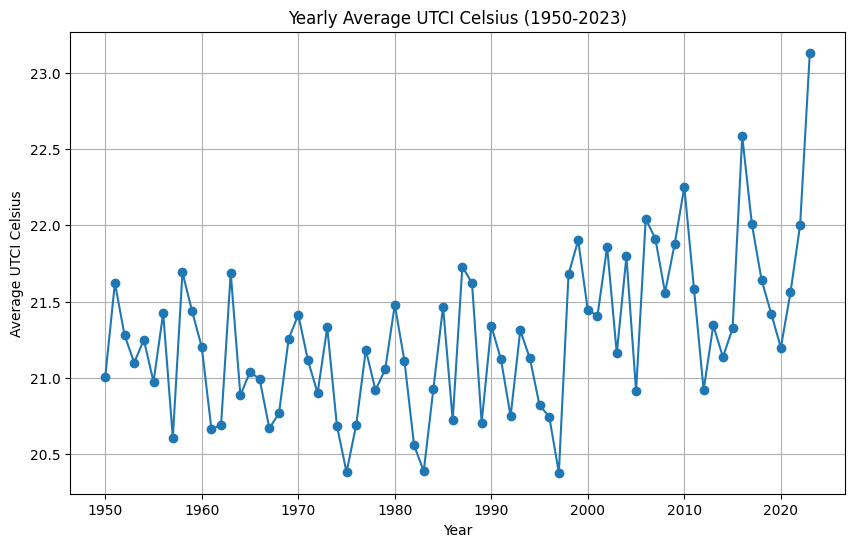

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
# Assuming your data is stored in a DataFrame called df
# Filter data for the desired period (1950-2023)
filtered_data = df[(df['year'] >= 1950) & (df['year'] <= 2023)]

# Aggregate data by year and calculate yearly averages
yearly_average = filtered_data.groupby('year')['utci_celsius'].mean().reset_index()

# Plotting the data
plt.figure(figsize=(10, 6))
plt.plot(yearly_average['year'], yearly_average['utci_celsius'], marker='o', linestyle='-')
plt.title('Yearly Average UTCI Celsius (1950-2023)')
plt.xlabel('Year')
plt.ylabel('Average UTCI Celsius')
plt.grid(True)
plt.show()


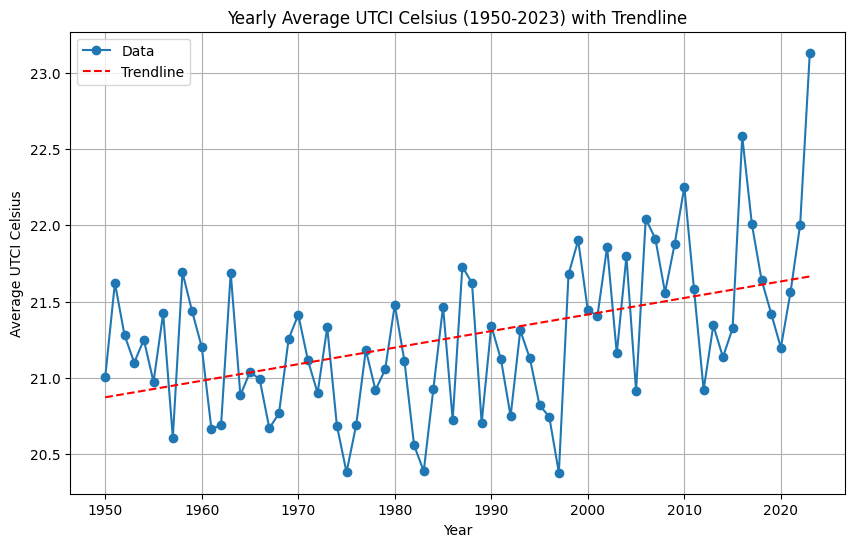

Slope of the trendline: 0.010842292743098841


In [ ]:
import numpy as np
from scipy.stats import linregress

# Fit a linear regression line to the data
slope, intercept, r_value, p_value, std_err = linregress(yearly_average['year'], yearly_average['utci_celsius'])

# Plotting the data with the regression line
plt.figure(figsize=(10, 6))
plt.plot(yearly_average['year'], yearly_average['utci_celsius'], marker='o', linestyle='-', label='Data')
plt.plot(yearly_average['year'], intercept + slope * yearly_average['year'], linestyle='--', color='red', label='Trendline')
plt.title('Yearly Average UTCI Celsius (1950-2023) with Trendline')
plt.xlabel('Year')
plt.ylabel('Average UTCI Celsius')
plt.legend()
plt.grid(True)
plt.show()

print("Slope of the trendline:", slope)


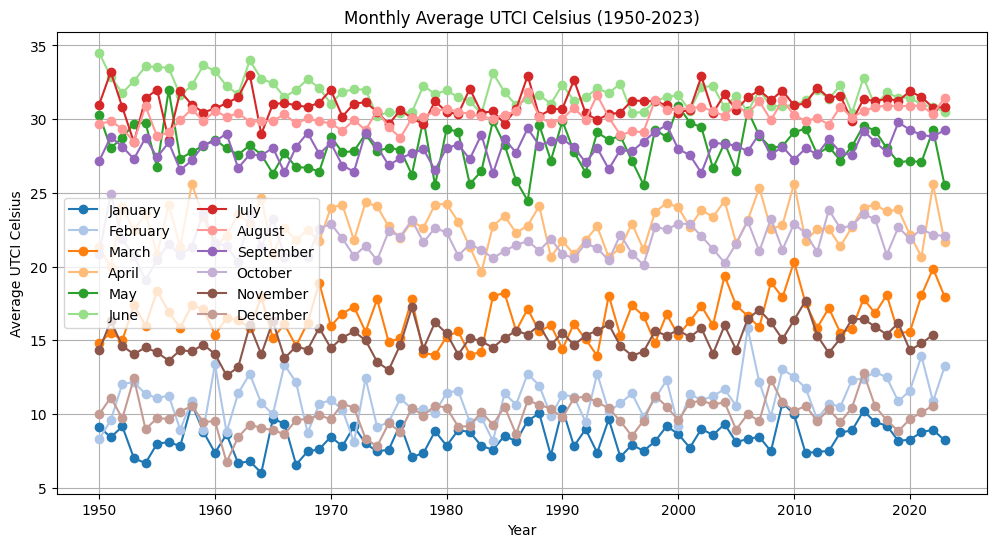

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar

# Filter data for the desired period (1950-2023)
filtered_data = df[(df['year'] >= 1950) & (df['year'] <= 2023)]

# Aggregate data by month and calculate monthly averages
monthly_average = filtered_data.groupby(['year', 'month'])['utci_celsius'].mean().reset_index()

# Convert month numbers to month names
monthly_average['month_name'] = monthly_average['month'].apply(lambda x: calendar.month_name[x])

# Define a color map for distinct colors for each month
colors = plt.get_cmap('tab20').colors  # tab20 colormap has 20 distinct colors

# Plotting the data
plt.figure(figsize=(12, 6))

# Plot each month's data separately with distinct colors
for i, month in enumerate(range(1, 13)):
    month_data = monthly_average[monthly_average['month'] == month]
    plt.plot(month_data['year'], month_data['utci_celsius'], marker='o', linestyle='-', color=colors[i], label=f'{calendar.month_name[month]}')

plt.title('Monthly Average UTCI Celsius (1950-2023)')
plt.xlabel('Year')
plt.ylabel('Average UTCI Celsius')
plt.legend(ncol=2)
plt.grid(True)
plt.show()


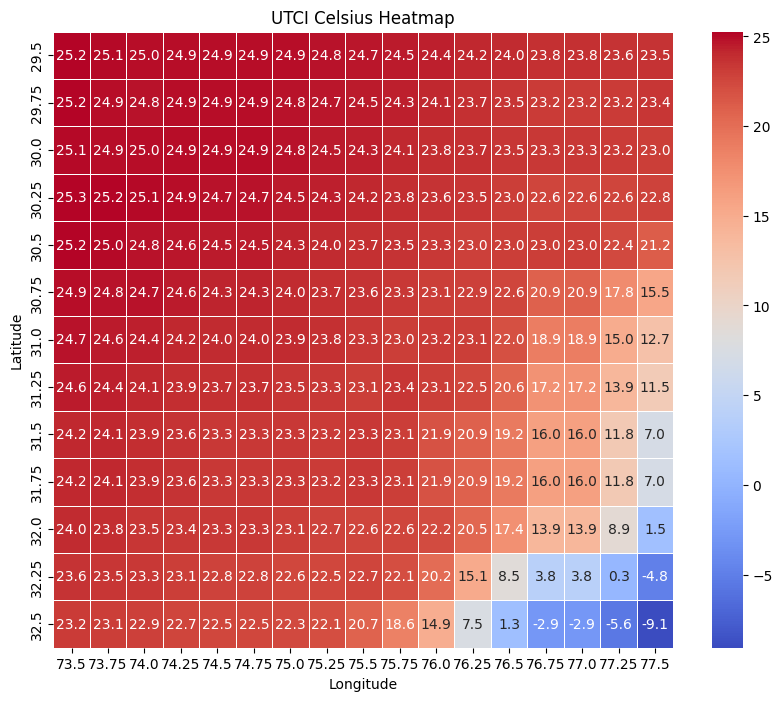

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap using Seaborn
plt.figure(figsize=(10, 8))
heatmap_data = df.pivot_table(values='utci_celsius', index='lat', columns='lon')
sns.heatmap(heatmap_data, cmap='coolwarm', annot=True, fmt=".1f", linewidths=.5)
plt.title('UTCI Celsius Heatmap')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [ ]:
# Filter the DataFrame to include only entries for Chandigarh's latitude and longitude
chandigarh_data = mdf[(mdf['lat'] == 30.75) & (mdf['lon'] == 76.00)]

print(chandigarh_data)


        year  month    lat   lon  utci_celsius       stress_category
95      1950      1  30.75  76.0     11.068808     No thermal stress
316     1950      2  30.75  76.0      9.738854     No thermal stress
537     1950      3  30.75  76.0     16.501578     No thermal stress
758     1950      4  30.75  76.0     24.479021     No thermal stress
979     1950      5  30.75  76.0     33.511678    Strong Heat Stress
...      ...    ...    ...   ...           ...                   ...
194796  2023      6  30.75  76.0     32.419168    Strong Heat Stress
195017  2023      7  30.75  76.0     32.037897    Strong Heat Stress
195238  2023      8  30.75  76.0     33.294733    Strong Heat Stress
195459  2023      9  30.75  76.0     31.449588  Moderate Heat Stress
195680  2023     10  30.75  76.0     24.259380     No thermal stress

[886 rows x 6 columns]


In [ ]:
def classify_utci(utci_celsius):
    if utci_celsius > 46:
        return 'Extreme Heat Stress'
    elif 38 <= utci_celsius <= 46:
        return 'Very Strong Heat Stress'
    elif 32 <= utci_celsius < 38:
        return 'Strong Heat Stress'
    elif 26 <= utci_celsius < 32:
        return 'Moderate Heat Stress'
    elif 9 <= utci_celsius < 26:
        return 'No thermal stress'
    elif 0 <= utci_celsius < 9:
        return 'Slight Cold Stress'
    elif -13 <= utci_celsius < 0:
        return 'Moderate Cold Stress'
    elif -27 <= utci_celsius < -13:
        return 'Strong Cold Stress'
    elif -40 <= utci_celsius < -27:
        return 'Very Strong Cold Stress'
    else:
        return 'Extreme Cold Stress'

mdf['stress_category'] = mdf['utci_celsius'].apply(classify_utci)

In [ ]:
mdf.head(10000)

,year,month,lat,lon,utci_celsius,stress_category
0,1950,1,29.50,73.50,12.004224,No thermal stress
1,1950,1,29.50,73.75,12.068523,No thermal stress
2,1950,1,29.50,74.00,12.196113,No thermal stress
3,1950,1,29.50,74.25,12.127976,No thermal stress
4,1950,1,29.50,74.50,12.033265,No thermal stress
...,...,...,...,...,...,...
9995,1953,10,30.00,77.50,23.060270,No thermal stress
9996,1953,10,30.25,73.50,24.693703,No thermal stress
9997,1953,10,30.25,73.75,24.704069,No thermal stress
9998,1953,10,30.25,74.00,24.587131,No thermal stress


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Pivot the DataFrame to reshape it
pivot_df = mdf.pivot_table(index='lat', columns='lon', values='utci_celsius')

# Extract values for x, y, and z axes
x = pivot_df.columns
y = pivot_df.index
z = pivot_df.values

# Create the 3D surface plot
fig = go.Figure(data=[go.Surface(z=z, x=x, y=y)])
fig.update_layout(title='3D Surface Plot of UTCi Celsius',
                  scene=dict(xaxis_title='Longitude',
                             yaxis_title='Latitude',
                             zaxis_title='UTCi Celsius'))
fig.show()


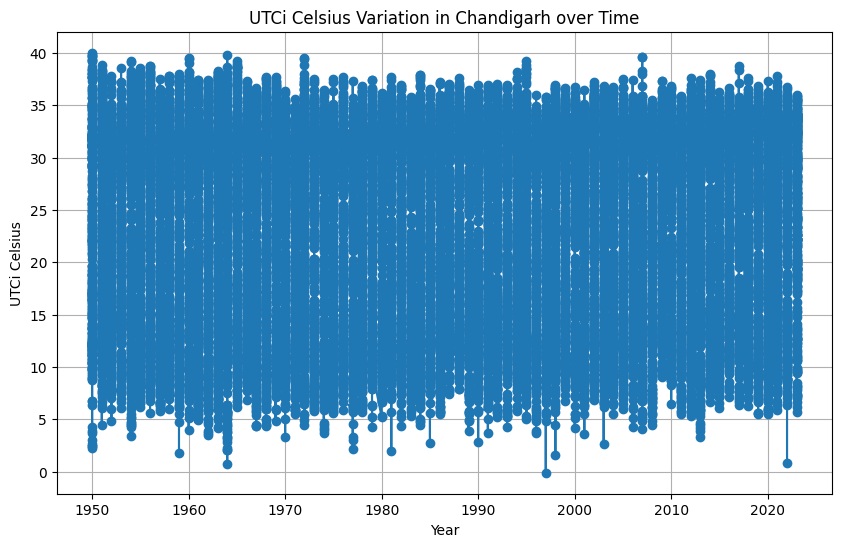

In [ ]:
import matplotlib.pyplot as plt

# Filter data for Chandigarh region
chandigarh_data = df[(df['lat'] == 30.75) & (df['lon'] == 76.0)]

# Plot line plot
plt.figure(figsize=(10, 6))
plt.plot(chandigarh_data['year'], chandigarh_data['utci_celsius'], marker='o', linestyle='-')
plt.title('UTCi Celsius Variation in Chandigarh over Time')
plt.xlabel('Year')
plt.ylabel('UTCi Celsius')
plt.grid(True)
plt.show()


if utci_celsius > 46:
        return 'Extreme Heat Stress'
    elif 38 <= utci_celsius <= 46:
        return 'Very Strong Heat Stress'
    elif 32 <= utci_celsius < 38:
        return 'Strong Heat Stress'
    elif 26 <= utci_celsius < 32:
        return 'Moderate Heat Stress'
    elif 9 <= utci_celsius < 26:
        return 'No thermal stress'
    elif 0 <= utci_celsius < 9:
        return 'Slight Cold Stress'
    elif -13 <= utci_celsius < 0:
        return 'Moderate Cold Stress'
    elif -27 <= utci_celsius < -13:
        return 'Strong Cold Stress'
    elif -40 <= utci_celsius < -27:
        return 'Very Strong Cold Stress'
    else:
        return 'Extreme Cold Stress'

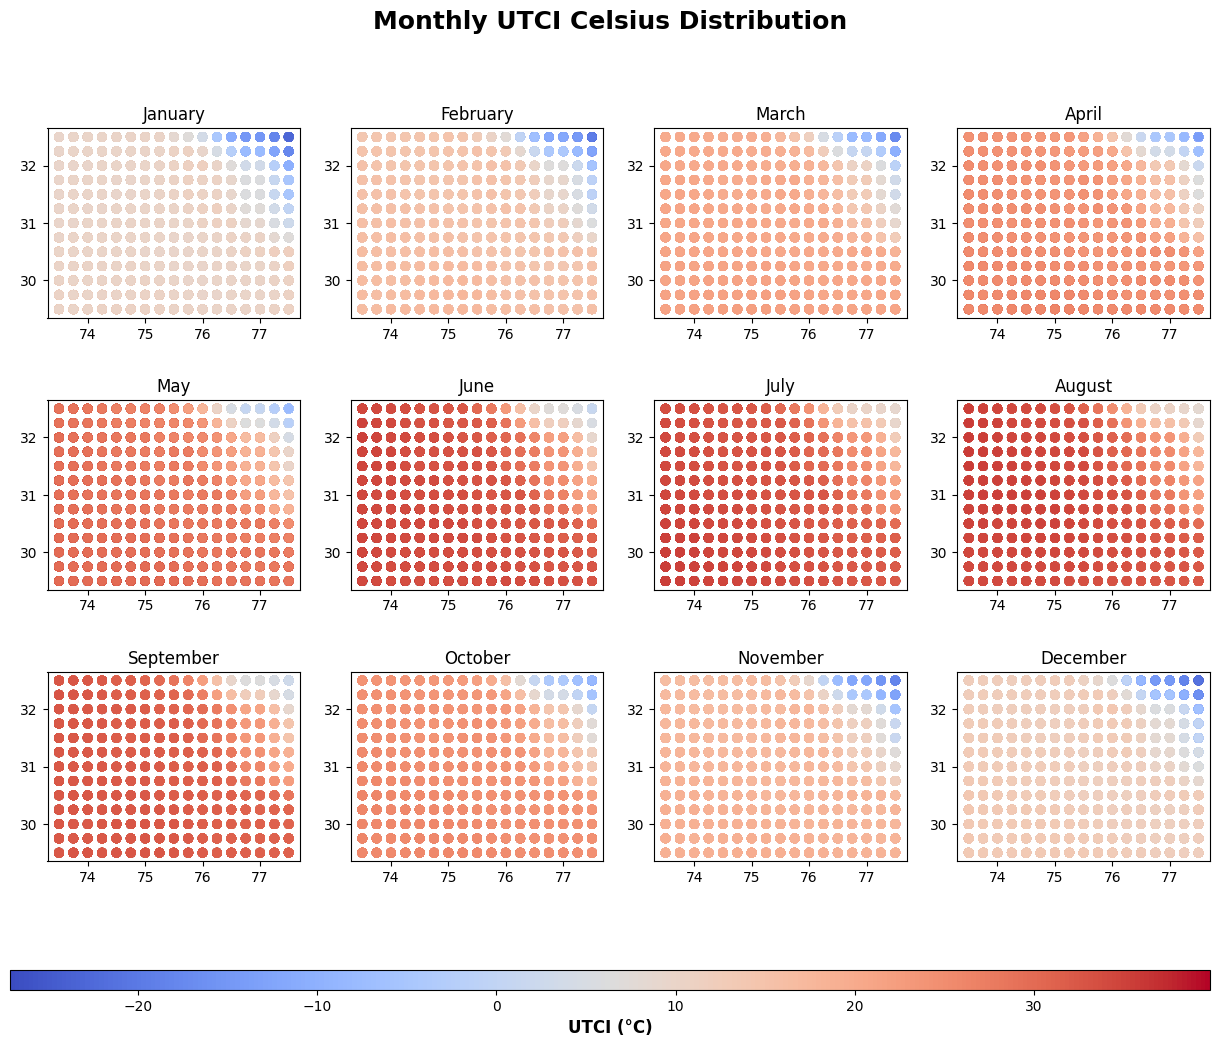

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import calendar

punjab_shapefile = "/content/drive/MyDrive/shape file/Punjab (1).shp"
punjab_boundaries = gpd.read_file(punjab_shapefile)

# Convert 'lat' and 'lon' columns in data to a GeoDataFrame
gdf_data = gpd.GeoDataFrame(mdf, geometry=gpd.points_from_xy(mdf['lon'], mdf['lat']))
# Define month names
month_names = [calendar.month_name[i] for i in range(1, 13)]
# Perform spatial join
merged_data = gpd.sjoin(gdf_data, punjab_boundaries, how="left", predicate="within")

# Calculate monthly climatology for each month
monthly_climatology = merged_data.groupby(['month'])['utci_celsius'].mean()

fig, axes = plt.subplots(3, 4, figsize=(15, 10))

# Define the range of UTCI values for consistent color coding
vmin = merged_data['utci_celsius'].min()
vmax = merged_data['utci_celsius'].max()

for month, ax in enumerate(axes.flat, start=1):
    ax.set_title(month_names[month-1])
    merged_data[merged_data['month'] == month].plot(column='utci_celsius', cmap='coolwarm', ax=ax, legend=False, vmin=vmin, vmax=vmax)

# Adjust color bar
cax = fig.add_axes([0.1, 0.0001, 0.8, 0.02])  # Adjusted position of the color bar
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label('UTCI (°C)', fontsize=12, fontweight='bold')  # Set orientation to horizontal
plt.suptitle('Monthly UTCI Celsius Distribution', fontsize=18, fontweight='bold')
plt.show()


In [ ]:
merged_data
gdf=merged_data

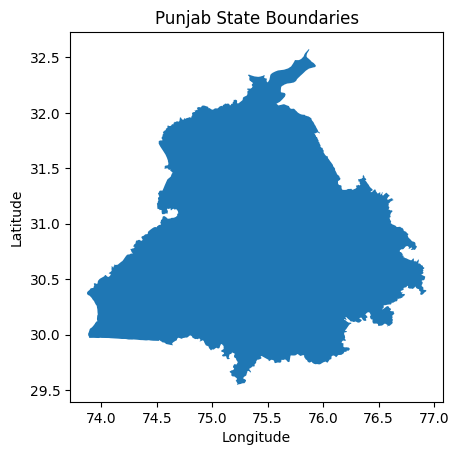

Longitude (x) coordinates:
0    75.40879
dtype: float64

Latitude (y) coordinates:
0    30.841465
dtype: float64


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt


# Extract x (longitude) and y (latitude) coordinates
x = punjab_boundaries.geometry.centroid.x
y = punjab_boundaries.geometry.centroid.y

# Plot Punjab boundaries
punjab_boundaries.plot()
plt.title('Punjab State Boundaries')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Print the first few values of x and y
print("Longitude (x) coordinates:")
print(x.head())
print("\nLatitude (y) coordinates:")
print(y.head())


In [ ]:
punjab_shapefile = "/content/drive/MyDrive/shape file/Punjab (1).shp"
punjab_boundaries = gpd.read_file(punjab_shapefile)
merged_data

In [ ]:
merged_data['geometry'] = merged_data.buffer(0.1)


<ipython-input-14-8ca59c5afc22>:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


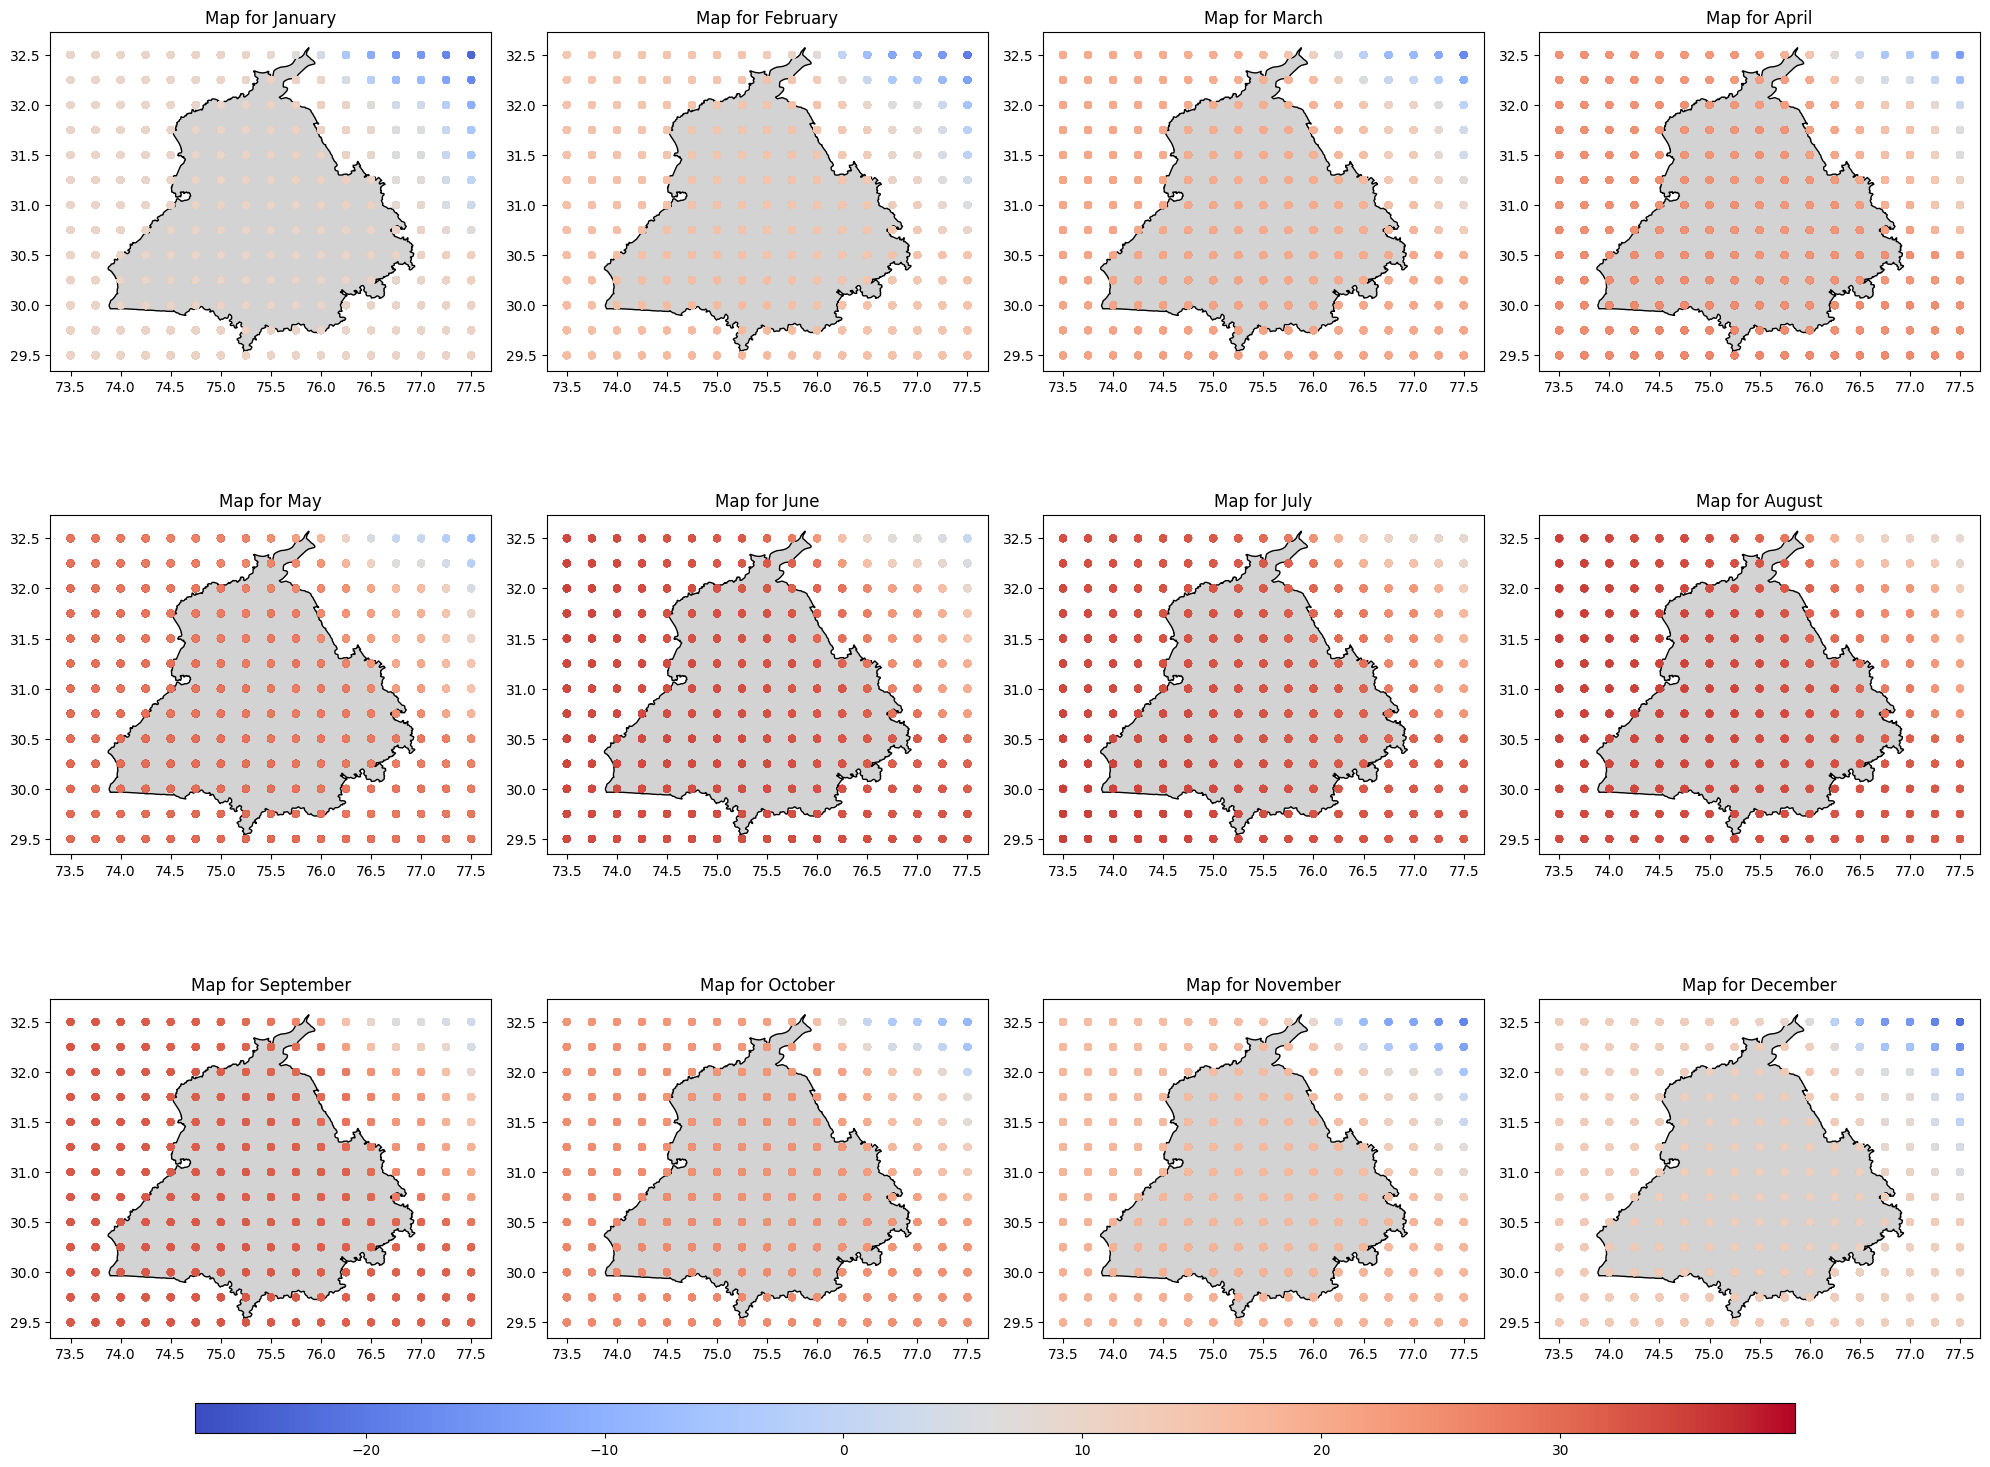

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
import calendar

# Load the data
data = mdf  # Replace 'your_data.csv' with the actual filename

# Convert the DataFrame to a GeoDataFrame
gdf = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data.lon, data.lat))

# Initialize variables to store min and max UTCI values across all months
min_utci = gdf['utci_celsius'].min()
max_utci = gdf['utci_celsius'].max()

# Load Punjab map data
punjab_map = gpd.read_file('/content/drive/MyDrive/shape file/Punjab (1).shp')  # Replace with the actual path

# Create subplots for each month
fig, axes = plt.subplots(3, 4, figsize=(20, 15))  # 3 rows, 4 columns for 12 months

# Define a normalization for the color bar
norm = Normalize(vmin=min_utci, vmax=max_utci)

# Iterate over each month
for month, ax in zip(range(1, 13), axes.flatten()):  # assuming months are represented as integers from 1 to 12
    # Filter data for the current month
    month_data = gdf[gdf['month'] == month]

    # Plot Punjab map
    punjab_map.plot(ax=ax, color='lightgrey', edgecolor='black')

    # Plot UTCI values with consistent color scale
    month_data.plot(column='utci_celsius', cmap='coolwarm', vmin=min_utci, vmax=max_utci, legend=False, ax=ax, markersize=20)

    ax.set_title(f'Map for {calendar.month_name[month]}')

cax = fig.add_axes([0.1, 0.001, 0.8, 0.02])  # Adjusted position of the color bar
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')  # Set orientation to horizontal

plt.tight_layout()
plt.show()


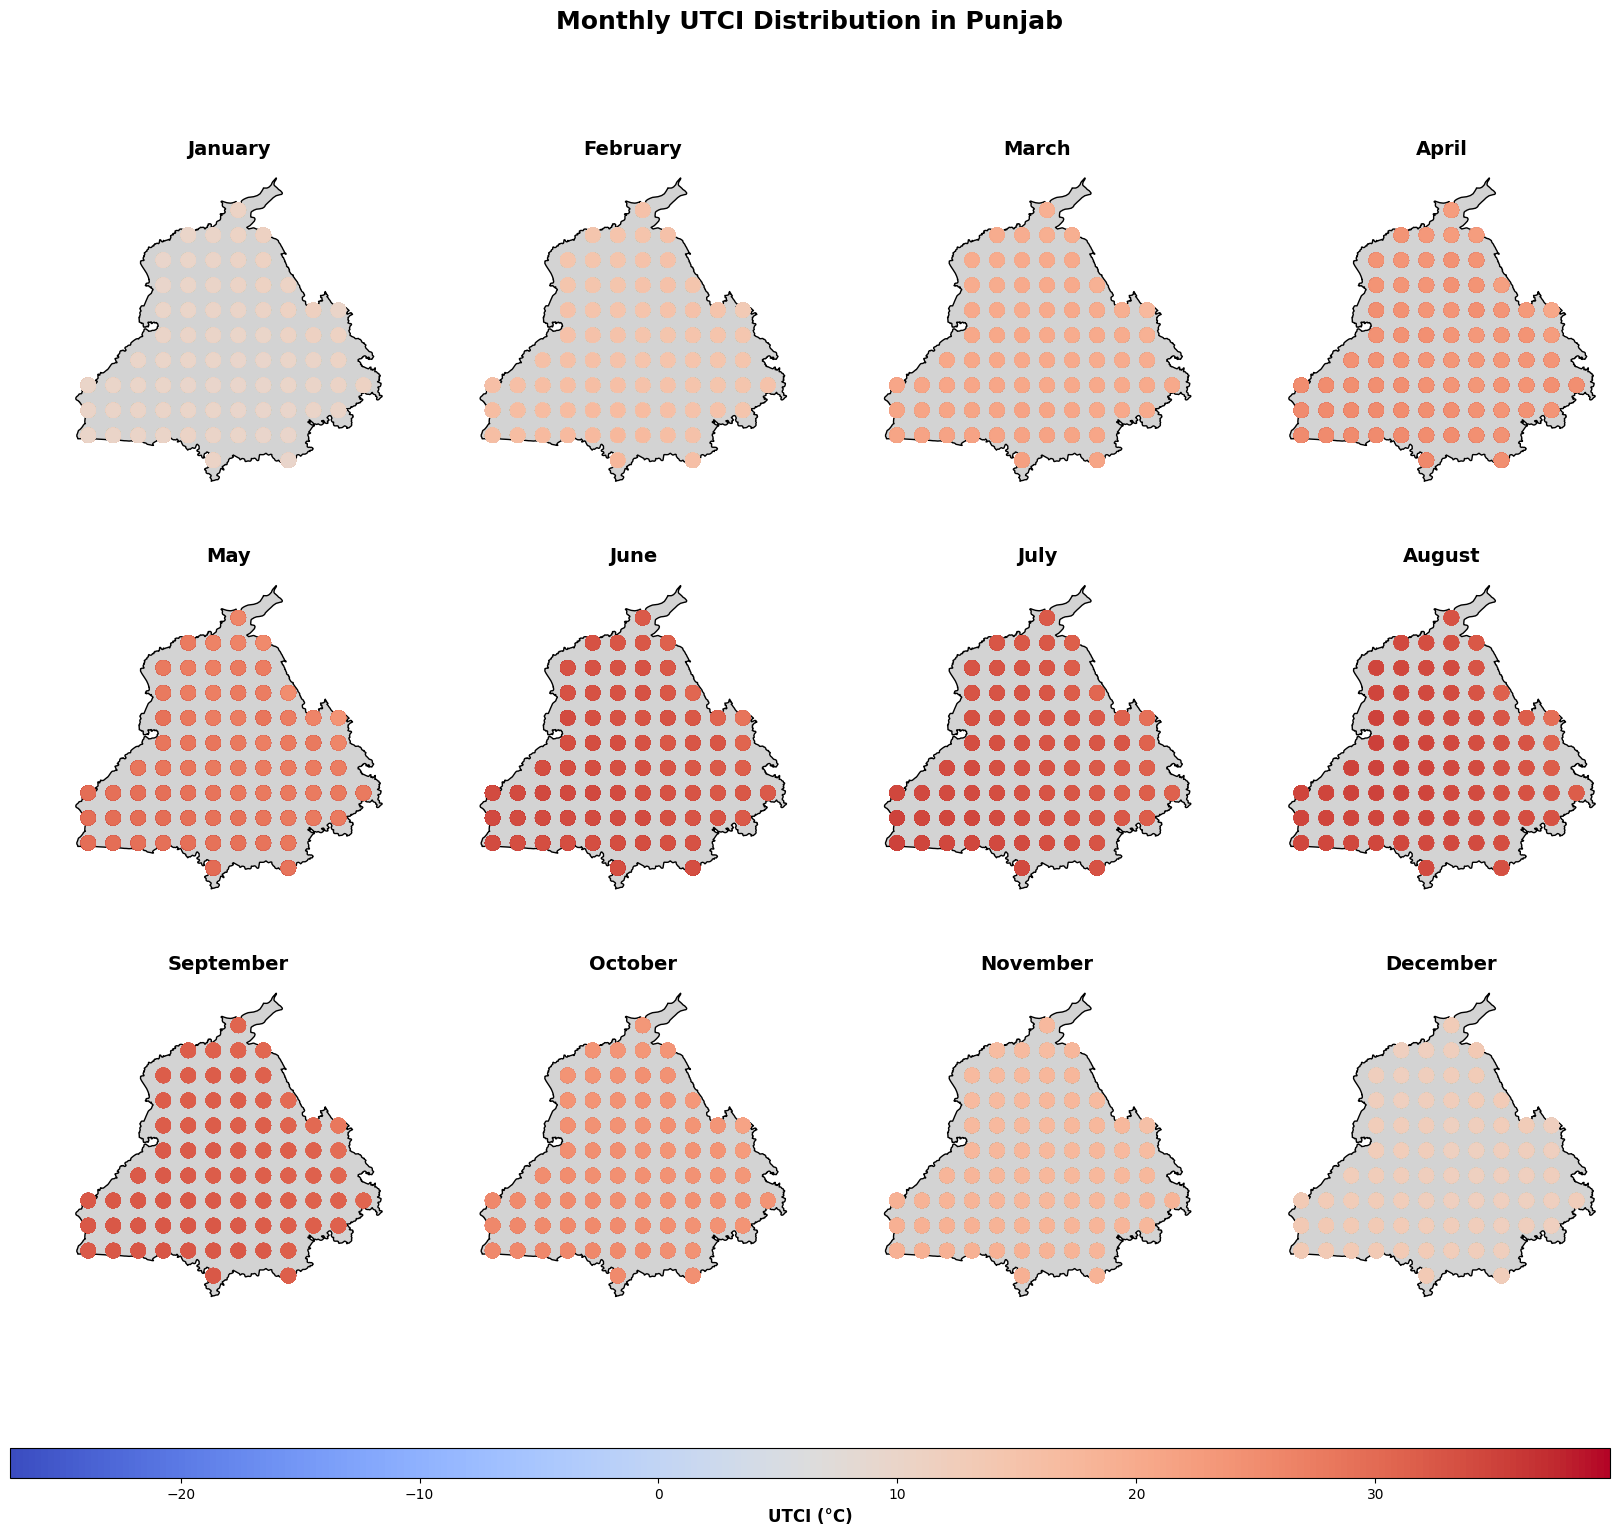

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# Load the data (assuming 'mdf' is already defined)
# Replace 'your_data.csv' with the actual filename
data = mdf

# Convert the DataFrame to a GeoDataFrame
gdf = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data.lon, data.lat))

# Initialize variables to store min and max UTCI values across all months
min_utci = gdf['utci_celsius'].min()
max_utci = gdf['utci_celsius'].max()

# Load Punjab map data
punjab_map = gpd.read_file('/content/drive/MyDrive/shape file/Punjab (1).shp')  # Replace with the actual path

# Create subplots for each month
fig, axes = plt.subplots(3, 4, figsize=(20, 15))  # 3 rows, 4 columns for 12 months

# Iterate over each month
for month, ax in zip(range(1, 13), axes.flatten()):  # assuming months are represented as integers from 1 to 12
    # Filter data for the current month
    month_data = gdf[gdf['month'] == month]

    # Plot Punjab map
    punjab_map.plot(ax=ax, color='lightgrey', edgecolor='black')

    # Plot UTCI values with consistent color scale, inside map boundary
    month_data_inside_map = gpd.sjoin(month_data, punjab_map, predicate='within')
    month_data_inside_map.plot(column='utci_celsius', cmap='coolwarm', vmin=min_utci, vmax=max_utci,
                               legend=False, ax=ax, markersize=100)

    ax.set_title(f'{calendar.month_name[month]}', fontsize=14, fontweight='bold')

    # Remove axis and labeling
    ax.axis('off')

# Add color bar
cax = fig.add_axes([0.1, 0.001, 0.8, 0.02])  # Adjusted position of the color bar
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=min_utci, vmax=max_utci))
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label('UTCI (°C)', fontsize=12, fontweight='bold')

plt.suptitle('Monthly UTCI Distribution in Punjab', fontsize=18, fontweight='bold')

# Remove tight_layout() and adjust the figure manually if needed
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


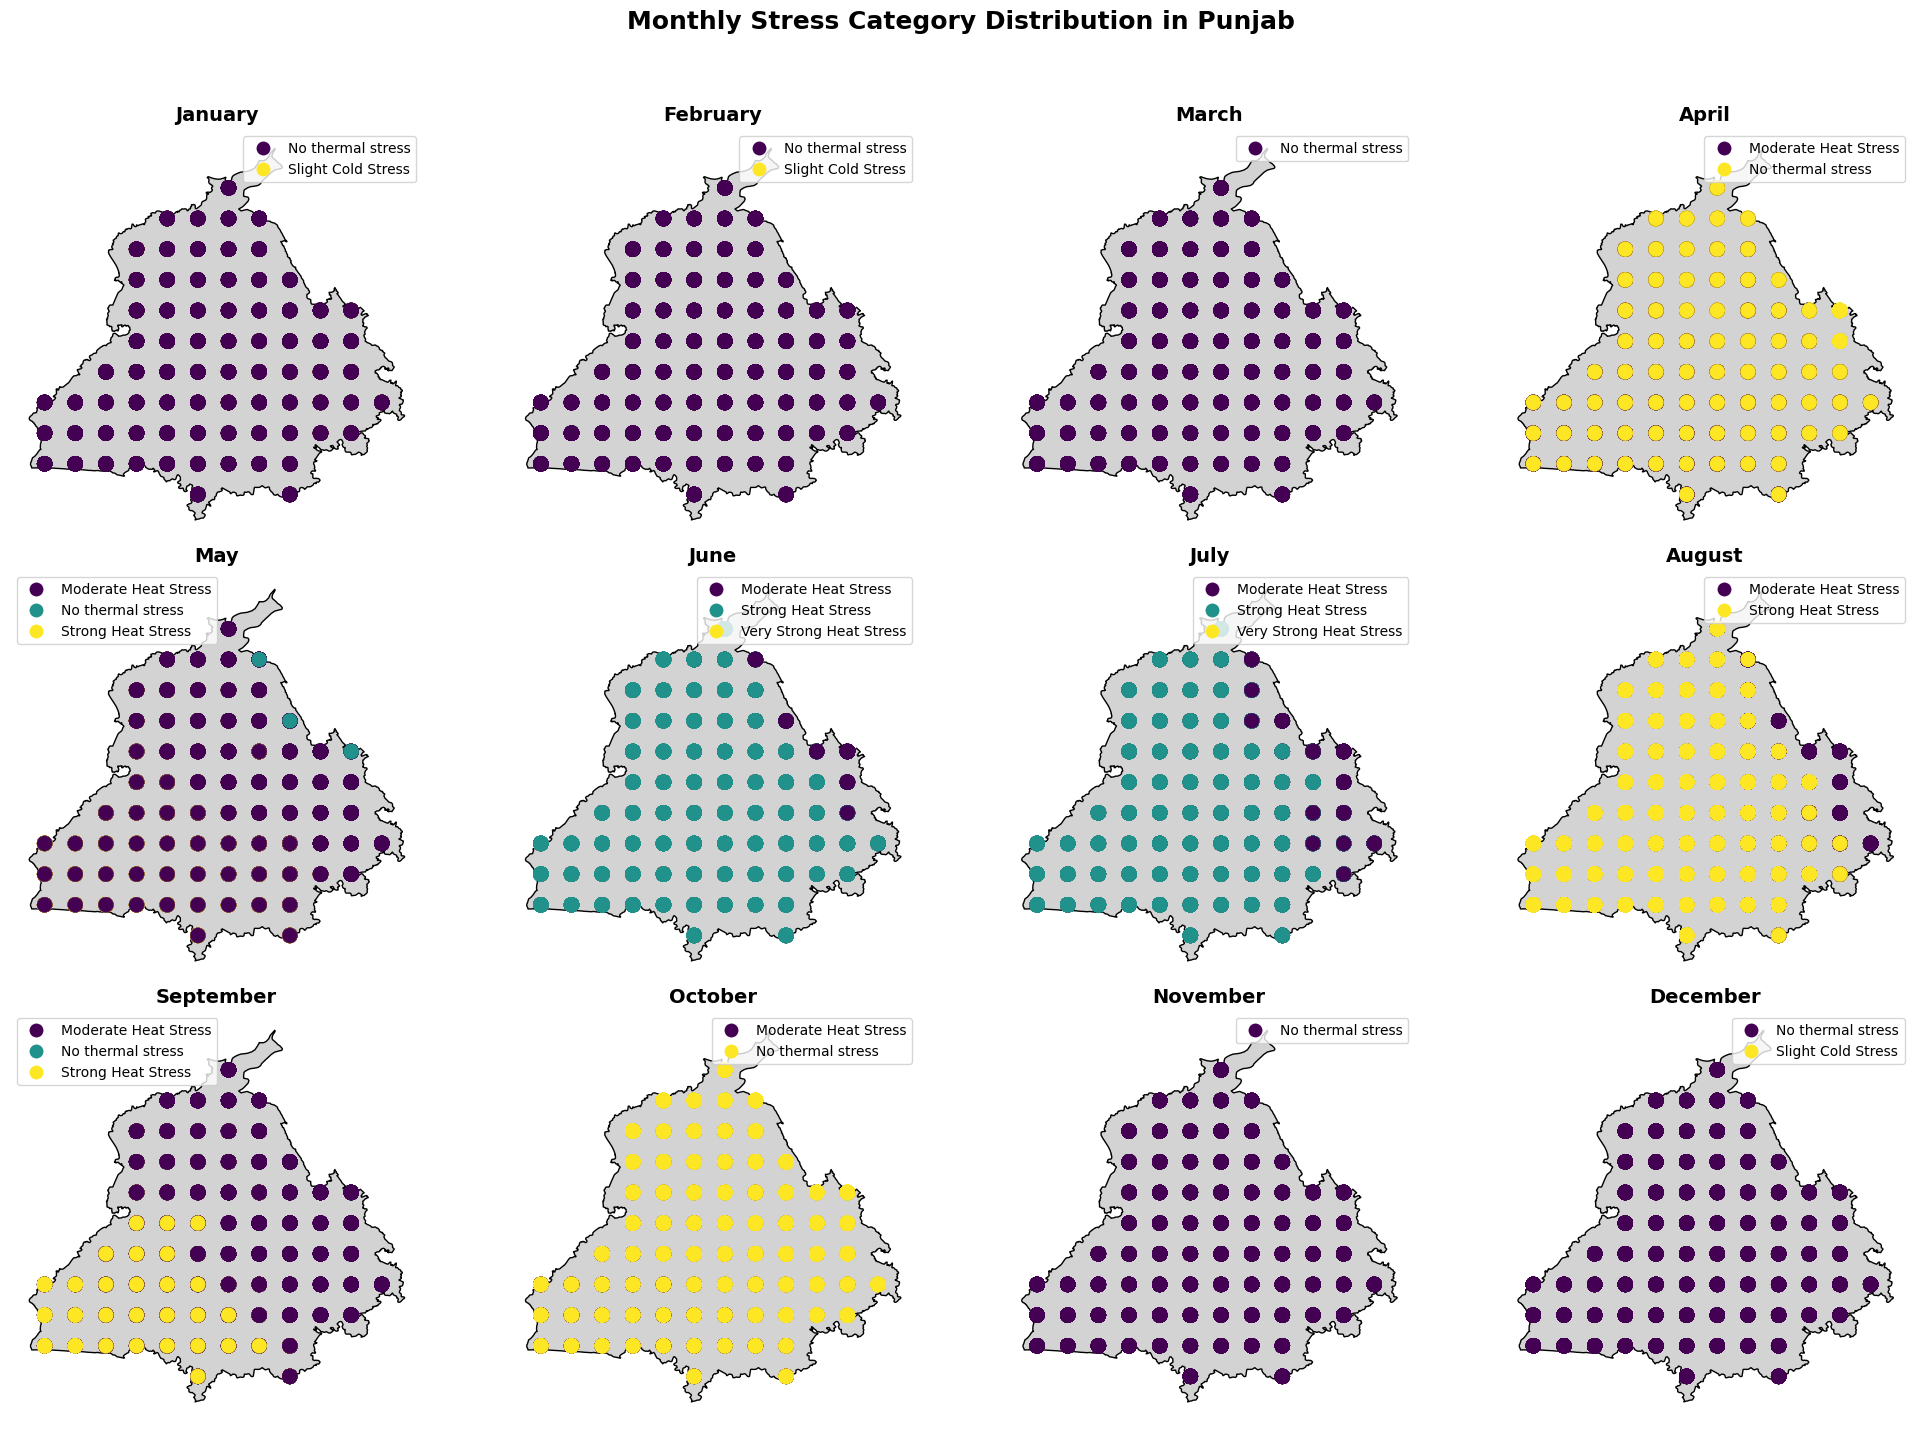

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import calendar

# Load the data
# Assuming 'data' is already defined with the DataFrame you provided
# Convert the DataFrame to a GeoDataFrame
gdf = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data.lon, data.lat))

# Load Punjab map data
punjab_map = gpd.read_file('/content/drive/MyDrive/shape file/Punjab (1).shp')  # Replace with the actual path

# Create subplots for each month
fig, axes = plt.subplots(3, 4, figsize=(20, 15))  # 3 rows, 4 columns for 12 months

# Iterate over each month
for month, ax in zip(range(1, 13), axes.flatten()):  # assuming months are represented as integers from 1 to 12
    # Filter data for the current month
    month_data = gdf[gdf['month'] == month]

    # Plot Punjab map
    punjab_map.plot(ax=ax, color='lightgrey', edgecolor='black')

    # Plot stress categories with consistent color scale, inside map boundary
    month_data_inside_map = gpd.sjoin(month_data, punjab_map, predicate='within')
    month_data_inside_map.plot(column='stress_category', cmap='viridis', legend=True, ax=ax, markersize=100)

    ax.set_title(f'{calendar.month_name[month]}', fontsize=14, fontweight='bold')

    # Remove axis and labeling
    ax.axis('off')

# Add color bar

plt.suptitle('Monthly Stress Category Distribution in Punjab', fontsize=18, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
gdf

plasma', 'inferno', or 'cividis

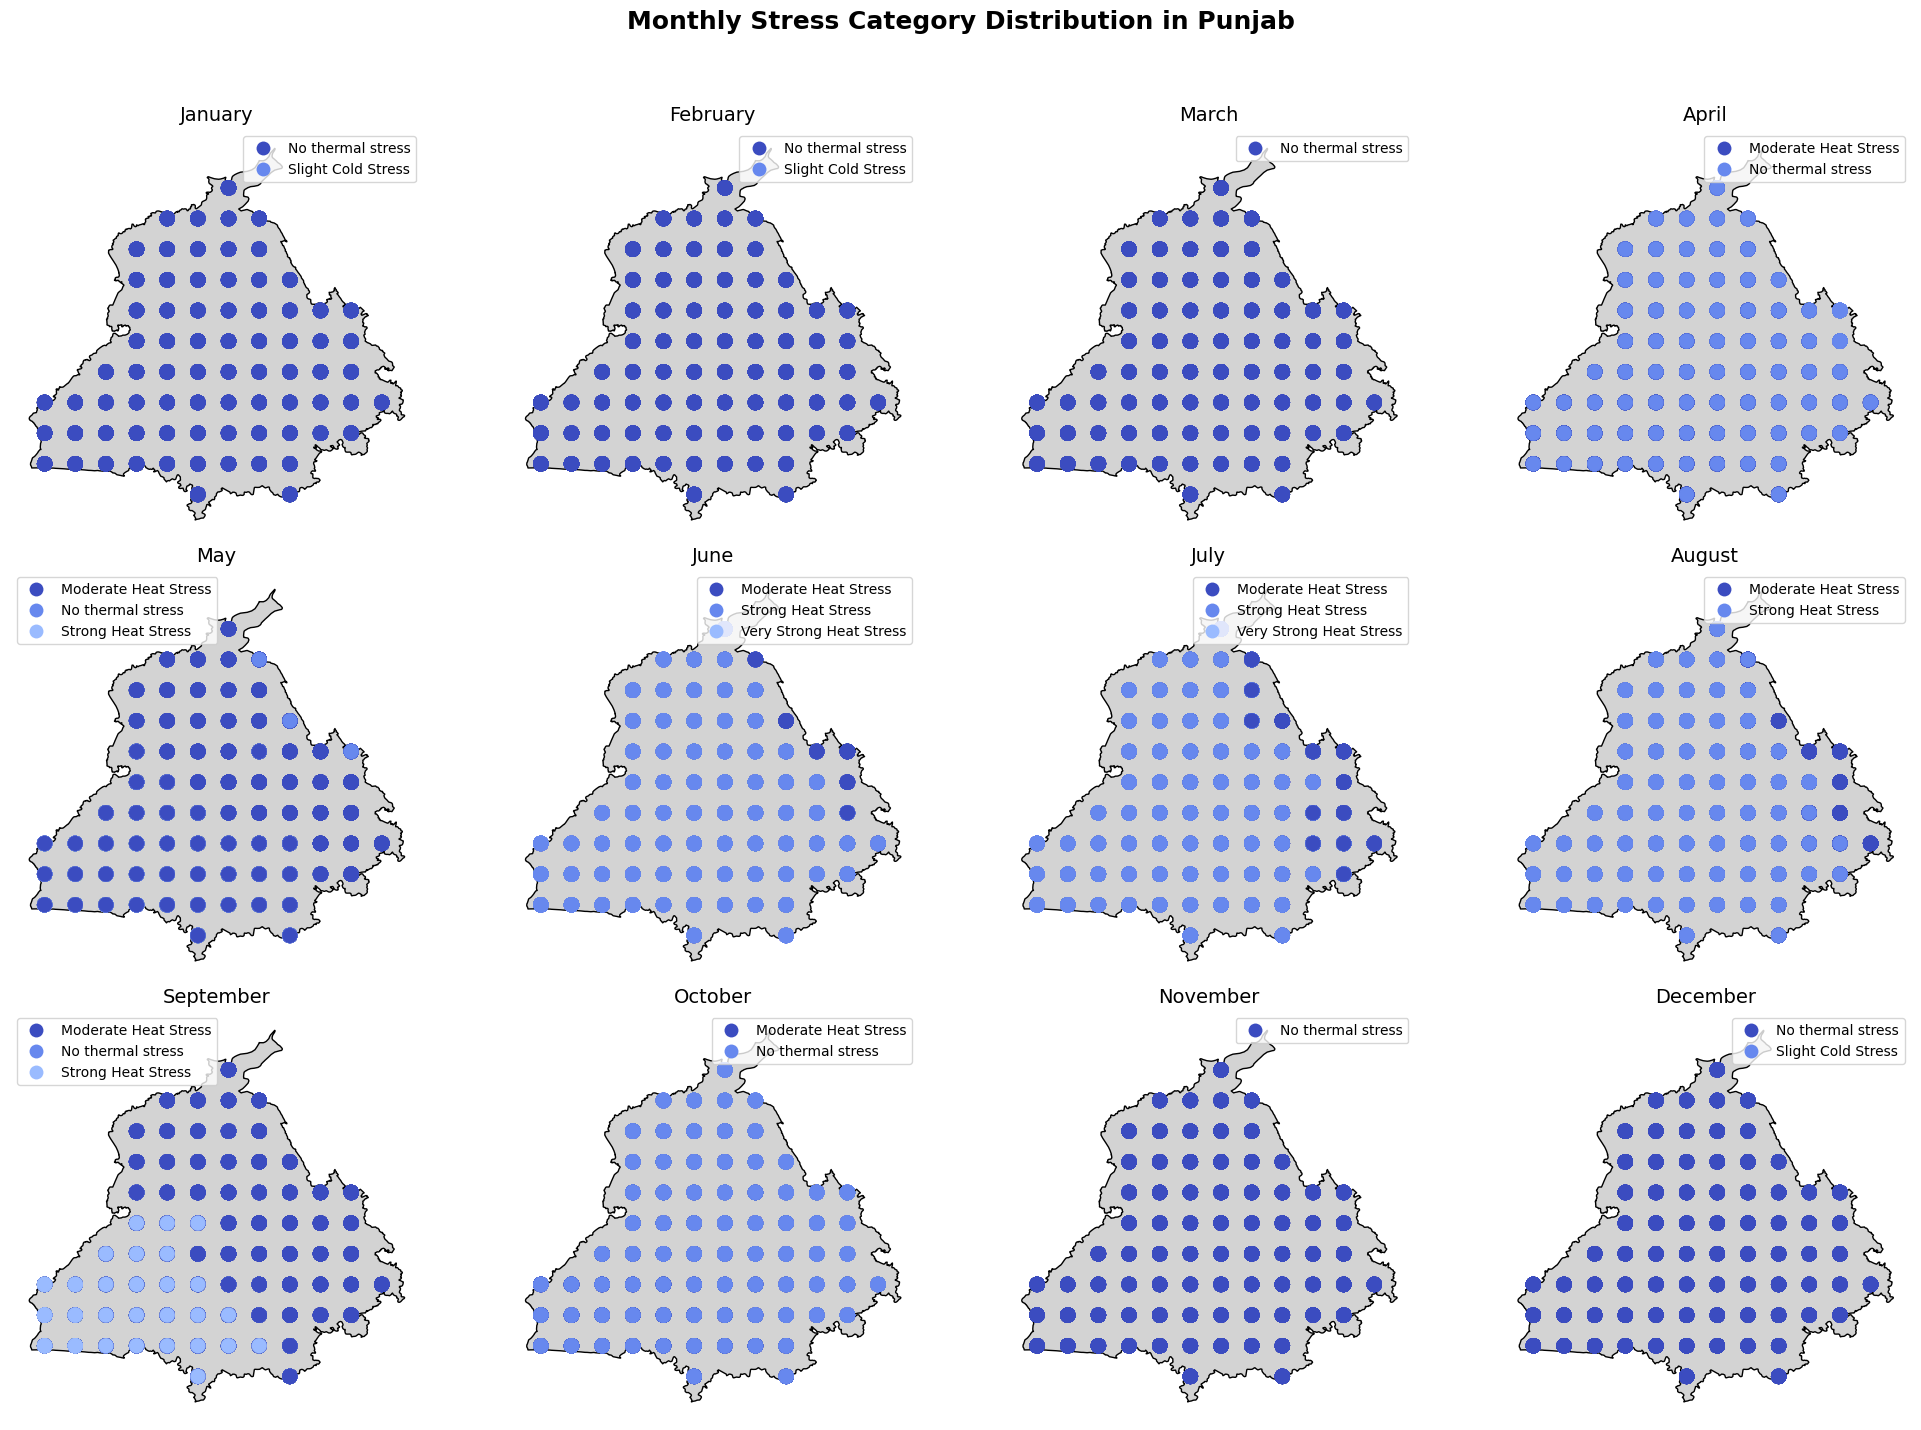

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import calendar

# Load the data (assuming 'data' is already defined)
gdf = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data.lon, data.lat))

# Load Punjab map data
punjab_map = gpd.read_file('/content/drive/MyDrive/shape file/Punjab (1).shp')  # Replace with the actual path

# Determine unique stress categories and map them to numerical values
stress_categories = gdf['stress_category'].unique()
category_mapping = {category: i for i, category in enumerate(stress_categories)}

# Create subplots for each month
fig, axes = plt.subplots(3, 4, figsize=(20, 15))  # 3 rows, 4 columns for 12 months

# Iterate over each month
for month, ax in zip(range(1, 13), axes.flatten()):
    # Filter data for the current month
    month_data = gdf[gdf['month'] == month]

    # Plot Punjab map
    punjab_map.plot(ax=ax, color='lightgrey', edgecolor='black')

    # Plot stress categories with a clearer color scale, inside map boundary
    month_data_inside_map = gpd.sjoin(month_data, punjab_map, predicate='within')
    month_data_inside_map.plot(column='stress_category', cmap='coolwarm', legend=True, ax=ax, markersize=100,
                               vmin=min(category_mapping.values()), vmax=max(category_mapping.values()))

    ax.set_title(f'{calendar.month_name[month]}', fontsize=14)

    # Add annotations for specific areas of high stress
    high_stress_areas = month_data_inside_map[month_data_inside_map['stress_category'] == 'High Stress']
    for x, y in zip(high_stress_areas.geometry.x, high_stress_areas.geometry.y):
        ax.text(x + 0.05, y + 0.05, '*', fontsize=12)

    # Remove axis and labeling
    ax.axis('off')

# Add color bar

plt.suptitle('Monthly Stress Category Distribution in Punjab', fontsize=18, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
